# Сборный проект

***Описание проекта***

Вы работаете в интернет-магазине «Стримчик», который продаёт по всему миру компьютерные игры. Из открытых источников доступны исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы (например, Xbox или PlayStation). Вам нужно выявить определяющие успешность игры закономерности. Это позволит сделать ставку на потенциально популярный продукт и спланировать рекламные кампании.
Перед вами данные до 2016 года. Представим, что сейчас декабрь 2016 г., и вы планируете кампанию на 2017-й. Нужно отработать принцип работы с данными. Неважно, прогнозируете ли вы продажи на 2017 год по данным 2016-го или же 2027-й — по данным 2026 года.
В наборе данных попадается аббревиатура ESRB (Entertainment Software Rating Board) — это ассоциация, определяющая возрастной рейтинг компьютерных игр. ESRB оценивает игровой контент и присваивает ему подходящую возрастную категорию, например, «Для взрослых», «Для детей младшего возраста» или «Для подростков».


***Описание данных***

    Name — название игры
    Platform — платформа
    Year_of_Release — год выпуска
    Genre — жанр игры
    NA_sales — продажи в Северной Америке (миллионы проданных копий)
    EU_sales — продажи в Европе (миллионы проданных копий)
    JP_sales — продажи в Японии (миллионы проданных копий)
    Other_sales — продажи в других странах (миллионы проданных копий)
    Critic_Score — оценка критиков (максимум 100)
    User_Score — оценка пользователей (максимум 10)
    Rating — рейтинг от организации ESRB (англ. Entertainment Software Rating Board). Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию.

Данные за 2016 год могут быть неполными.

## Шаг 1. Откройте файл с данными и изучите общую информацию

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st
import plotly.express as px
%matplotlib inline

Установим настройки для отображения всех колонок и строк при печати

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

Таблица games

In [3]:
games = pd.read_csv('/datasets/games.csv') #читаем файл и сохраняем его в переменной games

Посмотрим информацию о таблице

In [4]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
Name               16713 non-null object
Platform           16715 non-null object
Year_of_Release    16446 non-null float64
Genre              16713 non-null object
NA_sales           16715 non-null float64
EU_sales           16715 non-null float64
JP_sales           16715 non-null float64
Other_sales        16715 non-null float64
Critic_Score       8137 non-null float64
User_Score         10014 non-null object
Rating             9949 non-null object
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


Посчитаем количество пропусков 

In [5]:
games.isna().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64

Посчитаем количество дубликатов

In [6]:
games.duplicated().sum()

0

Видим пропуски в столбцах Name, Year_of_Release, Genre, Critic_Score, User_Score, Rating. Заполним их где возможно в следующем пункте, а также приведем названия столбцов к нижнему регистру. Ещё изменим тип данных столбцов Year_of_Release(год выпуска) на целочисленный и User_Score(оценка пользователей) на вещественный

Выведем первые 5 строк таблицы

In [7]:
games.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


### Вывод

Мы вгзлянули на таблицу, на информацию о ней, посчитали пропуски (в столбцах Name, Year_of_Release, Genre, Critic_Score, User_Score, Rating). Дубликатов нет. В следующем пункте приведем названия столбцов к нижнему регистру, заполним пропуски где это возможно, изменим тип данных некоторых столбцов.

## Шаг 2. Подготовьте данные

Заменяем названия столбцов (приводим к нижнему регистру)

In [8]:
games.columns = map(str.lower, games.columns)

Проверяем

In [9]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
name               16713 non-null object
platform           16715 non-null object
year_of_release    16446 non-null float64
genre              16713 non-null object
na_sales           16715 non-null float64
eu_sales           16715 non-null float64
jp_sales           16715 non-null float64
other_sales        16715 non-null float64
critic_score       8137 non-null float64
user_score         10014 non-null object
rating             9949 non-null object
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


Заменим тип данных столбца user_score на вещественный, а столбца year_of_release на целолчисленный.

In [10]:
games['user_score']=pd.to_numeric(games['user_score'], errors='coerce')

In [11]:
games['year_of_release'] = games['year_of_release'].astype('Int64')

Проверяем

In [12]:
games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
name               16713 non-null object
platform           16715 non-null object
year_of_release    16446 non-null Int64
genre              16713 non-null object
na_sales           16715 non-null float64
eu_sales           16715 non-null float64
jp_sales           16715 non-null float64
other_sales        16715 non-null float64
critic_score       8137 non-null float64
user_score         7590 non-null float64
rating             9949 non-null object
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


Удалим из таблицы строки с пропусками в столбцу genre и name (меньше 1 процента)

In [13]:
games=games[(~games['name'].isna())|(~games['genre'].isna())]

Пропуски в столбцах user_score и critic_score, rating мы не можем заполнить, рейтинг и возрастная категория слишком субъективны. Оставляем как есть 

Часть пропусков в столбце year_of_release заменим на года от той же игры только другой платформы. Напишем цикл, который поможет сделать замену на года тех у кого совпадает названия с игрой.

In [14]:
for i in games[games['year_of_release'].isnull() == True].index:  
    games['year_of_release'][i] = games.loc[games['name'] == games['name'][i], 'year_of_release'].max()

Аббревиатура TBD (в столбце user_score) - это то же самое, что неизвестное значение, поэтому заменим tbd на Nan

In [15]:
games['user_score'] = games['user_score'].replace('tbd', np.nan, regex=True)

Проверяем 

In [16]:
games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 11 columns):
name               16713 non-null object
platform           16713 non-null object
year_of_release    16567 non-null Int64
genre              16713 non-null object
na_sales           16713 non-null float64
eu_sales           16713 non-null float64
jp_sales           16713 non-null float64
other_sales        16713 non-null float64
critic_score       8137 non-null float64
user_score         7590 non-null float64
rating             9949 non-null object
dtypes: Int64(1), float64(6), object(4)
memory usage: 2.2+ MB


Посчитаем суммарные продажи во всех регионах и запишем в столбец all_sales

In [17]:
games['all_sales']=games['na_sales']+games['eu_sales']+games['jp_sales']+games['other_sales']

In [18]:
games.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16713 entries, 0 to 16714
Data columns (total 12 columns):
name               16713 non-null object
platform           16713 non-null object
year_of_release    16567 non-null Int64
genre              16713 non-null object
na_sales           16713 non-null float64
eu_sales           16713 non-null float64
jp_sales           16713 non-null float64
other_sales        16713 non-null float64
critic_score       8137 non-null float64
user_score         7590 non-null float64
rating             9949 non-null object
all_sales          16713 non-null float64
dtypes: Int64(1), float64(7), object(4)
memory usage: 2.3+ MB


### Вывод

Мы привели названия столбцов к нижнему регистру; заполнили пропуски где это было возможно (столбец 'year of release'); изменили тип данных столбца year_of_release на целочисленный, user_score на вещественный; посчитали суммарные продажи во всех регионах и записали их в отдельный столбец all_sales; заменили tbd в столбце rating на Nan

## Шаг 3. Проведите исследовательский анализ данных

Посмотрим сколько игр выпускалось в разные годы. С помощью сводной таблицы найдем количество игр в каждом году и сохраним в переменной games_count_years. Построим график 

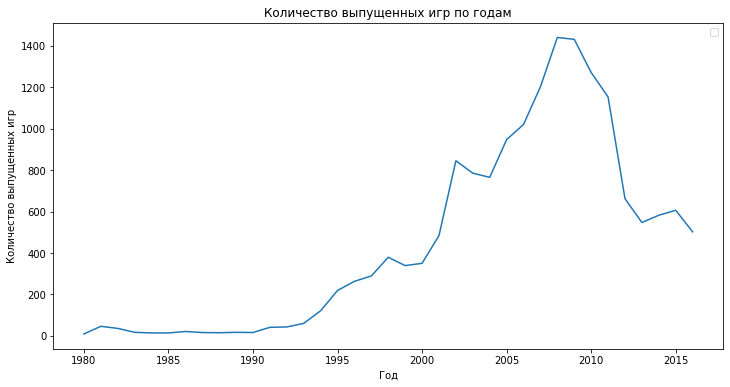

In [19]:
games_count_years = games.pivot_table(index='year_of_release', values='name', aggfunc='count')
plt.figure(figsize=(12,6))
sns.lineplot(data=games_count_years)
plt.title("Количество выпущенных игр по годам")
plt.xlabel("Год")
plt.ylabel("Количество выпущенных игр")
plt.legend('')
plt.show()

*Таким образом, видим, что только с 1990 года увеличивается количество выпускаемых игр в год, а с 2008 виден спад количества. Данные за 1980-1995 не очень важны, так как они не смогут помочь построить актуальный прогноз.*

Найдём продажи по платформам за все время. Выберим платформы (топ-3) с наибольшими суммарными продажами и построим их распределение по годам. 

С помощью сводной таблицы найдём суммарные продажи для каждый платформы за все время, отсоритруем по возрастанию, построим столбцатую диаграмму.

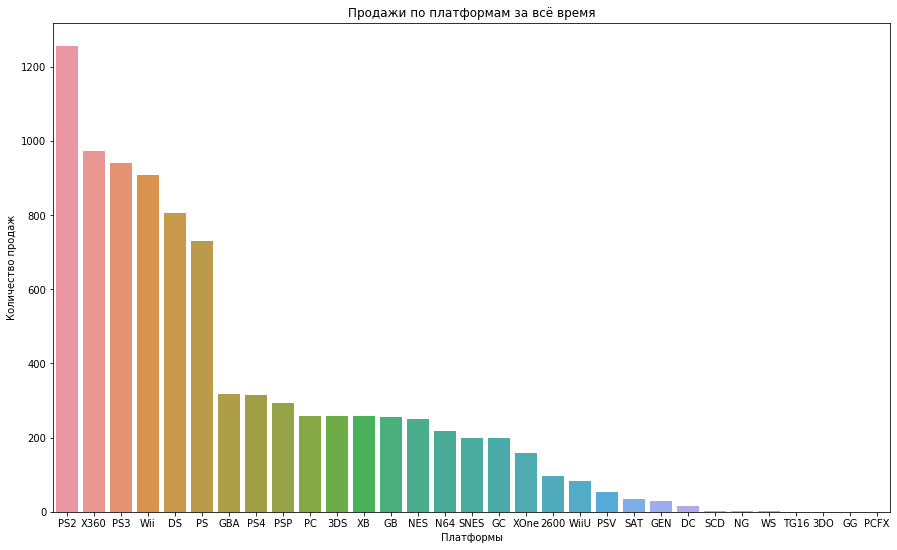

In [20]:
games_platform_sales = games.pivot_table(index='platform', values='all_sales', aggfunc='sum').sort_values(
    by='all_sales', ascending=False).reset_index()

plt.figure(figsize=(15,9))
sns.barplot(x=games_platform_sales['platform'],y=games_platform_sales['all_sales'])
plt.title("Продажи по платформам за всё время")
plt.xlabel("Платформы")
plt.ylabel("Количество продаж")
plt.show()

*Таким образом, топ-3 платформы с наибольшими продажами это PS2, X360, PS3.* Посмотрим их распределение по годам. С помощью сводной таблицы найдем сумму продаж по годам для каждой платформы, построим столбчатые диаграммы.

In [21]:
games_ps2=games[games['platform'] == 'PS2'].pivot_table(index='year_of_release', values='all_sales', aggfunc='sum')
games_x360=games[games['platform'] == 'X360'].pivot_table(index='year_of_release', values='all_sales', aggfunc='sum')
games_ps3=games[games['platform'] == 'PS3'].pivot_table(index='year_of_release', values='all_sales', aggfunc='sum')

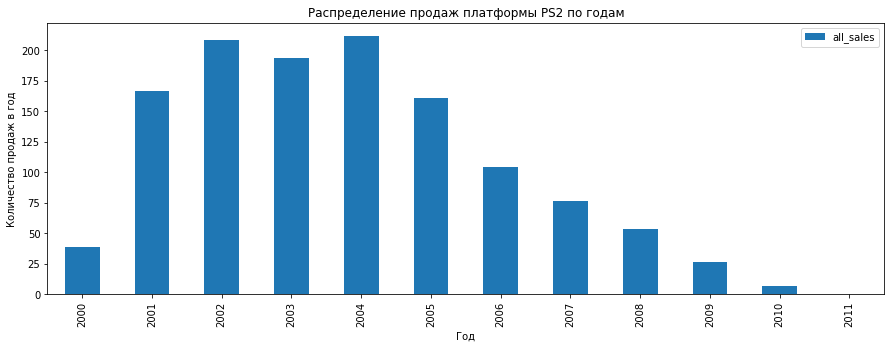

In [22]:
games_ps2.plot(kind='bar', figsize=(15,5))
plt.title("Распределение продаж платформы PS2 по годам")
plt.xlabel("Год")
plt.ylabel("Количество продаж в год")
plt.show()

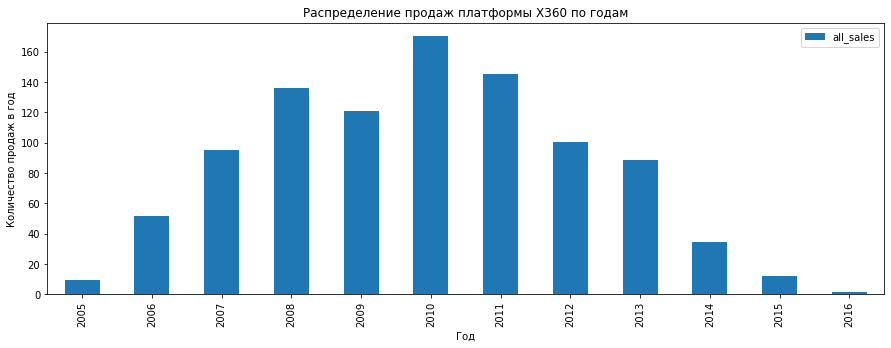

In [23]:
games_x360.plot(kind='bar', figsize=(15,5))
plt.title("Распределение продаж платформы X360 по годам")
plt.xlabel("Год")
plt.ylabel("Количество продаж в год")
plt.show()

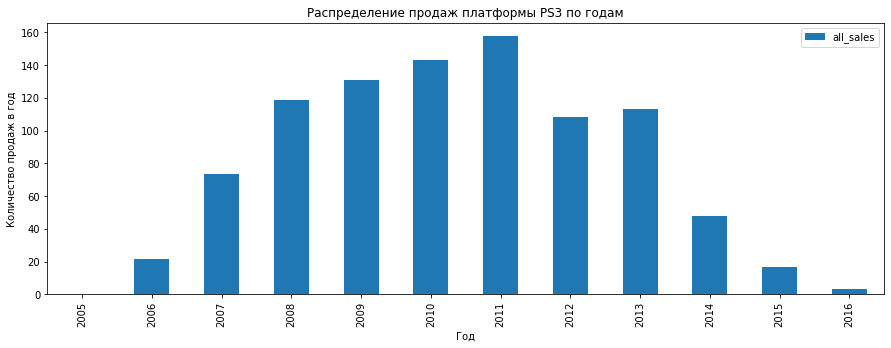

In [24]:
games_ps3.plot(kind='bar', figsize=(15,5))
plt.title("Распределение продаж платформы PS3 по годам")
plt.xlabel("Год")
plt.ylabel("Количество продаж в год")
plt.show()

А теперь для наглядности посмотрим на поведение топ-3 платформ по продажам (с помощью цикла построим зависимость числа продаж за года для каждой платформы, посмотрим на поведение платформ)

In [25]:
games_ps2=games_ps2.reset_index()
games_ps2.columns=['year','all_sales_year']
games_x360=games_x360.reset_index()
games_x360.columns=['year','all_sales_year']
games_ps3=games_ps3.reset_index()
games_ps3.columns=['year','all_sales_year']

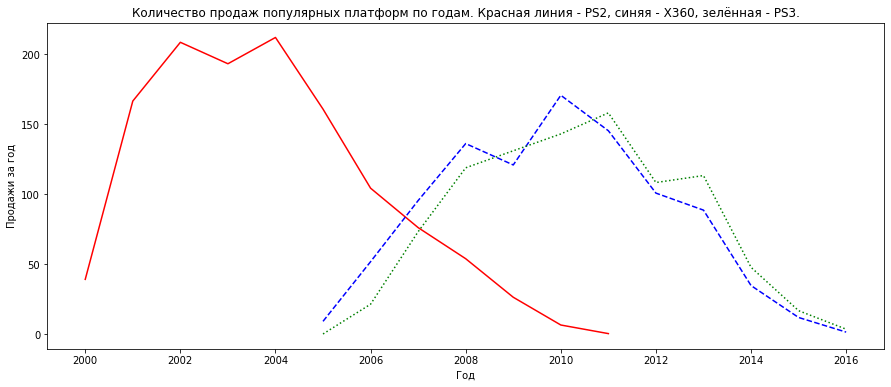

In [26]:
x1=games_ps2['year']
x2=games_x360['year']
x3=games_ps3['year']
y1=games_ps2['all_sales_year']
y2=games_x360['all_sales_year']
y3=games_ps3['all_sales_year']

plt.figure(figsize=(15,6))
plt.title('Количество продаж популярных платформ по годам. Красная линия - PS2, синяя - X360, зелённая - PS3.')
plt.xlabel('Год')
plt.ylabel('Продажи за год')
plt.plot(x1, y1, 'r-', x2, y2, 'b--', x3, y3, 'g:')
plt.show()

*Теперь проанализировав графика топ-3 платформы по сумме продаж, мы видим:*

    1) Игры на платформе PS2 продавались с 2000 по 2011 год. То есть PS2 "просущестовал" 12 лет, на 5 год сущестования(2004г) были самые большие продажи, а на последний год существования (2011г) их было меньше всего.
    2) Игры на платформе X360 продавались с 2005 по 2016 год. То есть X360 "просущестовал" 12 лет, на 6 год существоания (2010г) были самые большие продажи, а на последний год сущестования (2016г) их было меньше всего.
    3) Игры на платформе PS3 продавались с 2005 по 2016 год. То есть PS3 "просущестовал" 12 лет, на 7 год существоания (2011г) были самые большие продажи, а  на первый год сущестования (2005г) их было меньше всего.
    4) На 6 год сущестования PS2 (2005г) появились новые платформы PS3 и X360, а уже в 2011г (на 12 год сущестования) PS2 "исчезла", то есть на 6 год сущестования PS3 и X360
    5) А вот PS2 и X360 "появились" одновременно в 2005г и "исчезли" одновременно в 2016г. Но самые маленькие и большие продажи этих двух платформ пришлись на разные годы сущестования. В 2016 году они теряют своё могущество.


*Теперь надо выбрать период времени, который поможет построить прогноз на 2017 год, а потом мы возьмем данные за актуальный период и добавим в переменную actual_games:*

1) После пика продаж 2008 года (все платформы) - мы заметили понижение количества выпускаемых игр за год
2) Некоторых платформ уже "нет" в 2016 году, в построении прогноза на 2017 год они нам не помогут.
3) При уменьшении периода в рассмотрение попадут только актуальнные платформ

*Таким образом за актуальный период времени возьмем данные 2010 года и позже*

In [27]:
actual_games=games[games['year_of_release']>2009].reset_index()

Посмотрим на первые 5 строк

In [28]:
actual_games.head()

,index,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,all_sales
0,14,Kinect Adventures!,X360,2010,Misc,15.00,4.89,0.24,1.69,61.0,6.3,E,21.82
1,16,Grand Theft Auto V,PS3,2013,Action,7.02,9.09,0.98,3.96,97.0,8.2,M,21.05
2,23,Grand Theft Auto V,X360,2013,Action,9.66,5.14,0.06,1.41,97.0,8.1,M,16.27
3,27,Pokemon Black/Pokemon White,DS,2010,Role-Playing,5.51,3.17,5.65,0.80,NaN,NaN,NaN,15.13
4,29,Call of Duty: Modern Warfare 3,X360,2011,Shooter,9.04,4.24,0.13,1.32,88.0,3.4,M,14.73


А теперь рассмотрим платформы в actual_games. Напишем функцию, которая будет строить столбчатые диаграммы распределения продаж платформы по годам.

In [29]:
def pivot_bar(df, name):
    data=df[df['platform'] == name].pivot_table(index='year_of_release', values='all_sales', aggfunc='sum')
    data.plot(kind='bar', figsize=(10,3))
    plt.title('Распределение продаж платформы'+' '+name+' по годам')
    plt.xlabel("Год")
    plt.ylabel("Количество продаж в год")
    plt.show()

PS2, PS3, X360 рассматривать не будем. Мы их рассматривали выше. 

In [30]:
actual_games_platforms = actual_games[(actual_games['platform']!='PS3')&(actual_games['platform']!='PS2')&(actual_games['platform']!='X360')]

In [31]:
actual_games_platforms['platform'].unique()

array(['DS', 'PS4', '3DS', 'Wii', 'XOne', 'WiiU', 'PC', 'PSP', 'PSV'],
      dtype=object)

Теперь рассматриваем распределение продаж по годам всех платформ в актуальном периоде 

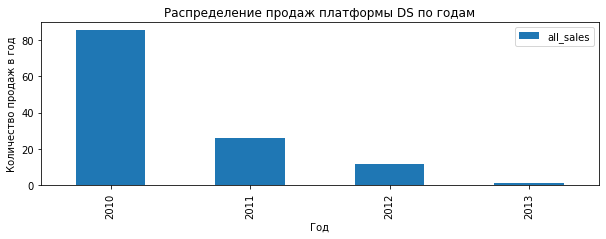

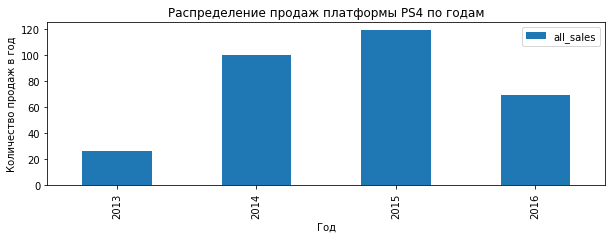

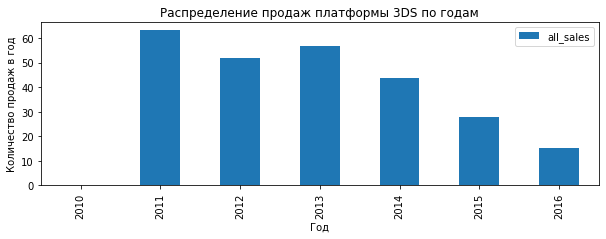

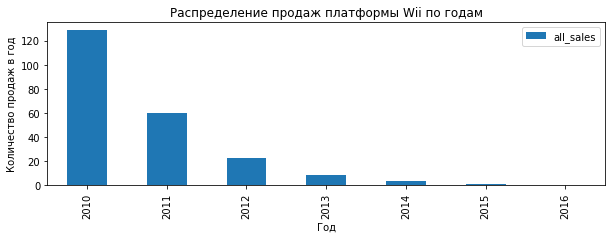

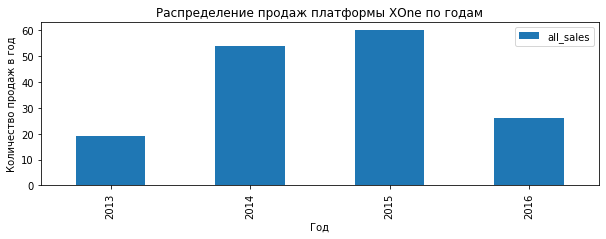

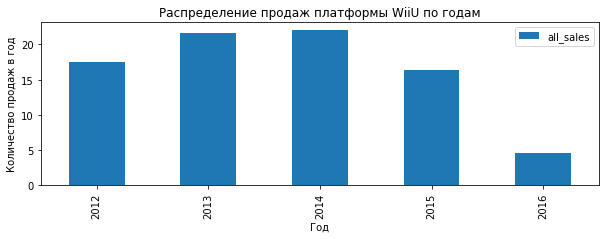

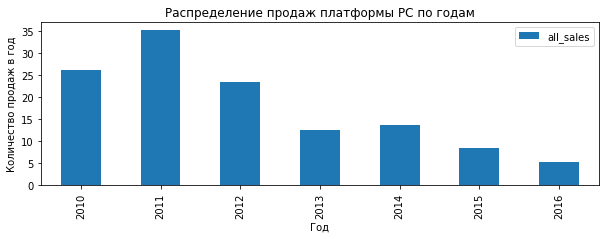

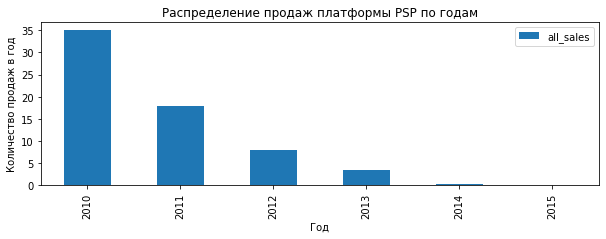

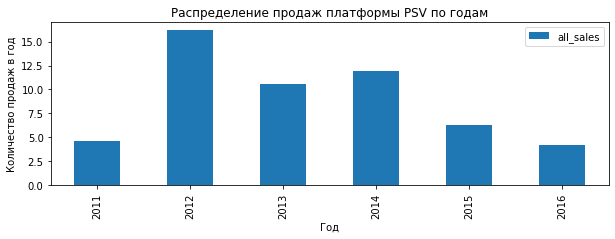

In [32]:
for i in ('DS', 'PS4', '3DS', 'Wii', 'XOne', 'WiiU', 'PC', 'PSP', 'PSV'):
    pivot_bar(actual_games_platforms, i)

*Видим, что:*

    1. Продажи DS за данный период постоянно падают, к 2013 году они сошли на нет, для анализа (прогноза на 2017 год) - это платформа не нужна.
    2. С 2013 по 2015 видим повышение количества продаж PS4, с 2015-2016 видим спад продаж, но они все равно остаются на неплохом уровне - на 2017 это потенциально прибыльная платформа
    3. Продажи 3DS постоянно подают, к 2016 году ее продажи очень малы - но все же за 2017 год эта платформа потенциально должна принести прибыль.
    4. Продажи Wii постоянно подают, к 2016 году ее продажи сошли на нет, поэтому в 2017 году данная платформа не будет потенциально прибыльной
    5. C 2013 по 2015 увеличиваются продаж XOne, к 2016 видим спад, но продажи все равно неплохие, за 2017 год эта платформа потенциально должна принести прибыль
    6. С 2015-2016 замечаем понижение продаж WiiU, а с 2012-2014 наоборот было повышение. 
    7. С 2011-2016 видим спад числа продаж PC
    8. Продажи PSP с 2010 по 2015 падали, данная платформа для прогноза не нужна
    9. С 2011-2012  и с 2013-2014 видим повышение числа продаж PSV, а с 2012-2013 и с 2014-2016 понижение продаж, эта платформа потенциально должна принести прибыль
    

***Построим график «ящик с усами» по глобальным продажам каждой игры и разбивкой по платформам***

Сохраним в переменной actual_platforms только платформы, которые не "умерли" к 2016 году или потенциально прибыльные(это мы выяснили чуть выше, а также еще выше рассмотрели PS2,PS3,X360 и к 2016г их продажи "были на нуле").

In [33]:
actual_platform = actual_games[~(actual_games['platform'].isin(['PS2','PS3','X360','DS','Wii','PSP']))]

Посмотрим на количество игр каждой платформы, а также на средние глобальные продажи по платформам

In [34]:
actual_platform.groupby('platform')['all_sales'].describe()

,count,mean,std,min,25%,50%,75%,max
platform,,,,,,,,
3DS,515.0,0.502000,1.437252,0.01,0.05,0.12,0.335,14.60
PC,488.0,0.255779,0.529919,0.01,0.03,0.08,0.230,5.14
PS4,392.0,0.801378,1.609456,0.01,0.06,0.20,0.730,14.63
PSV,429.0,0.125431,0.212341,0.01,0.02,0.05,0.130,1.96
WiiU,147.0,0.559116,1.058836,0.01,0.08,0.22,0.525,7.09
XOne,247.0,0.645020,1.036139,0.01,0.06,0.22,0.685,7.39


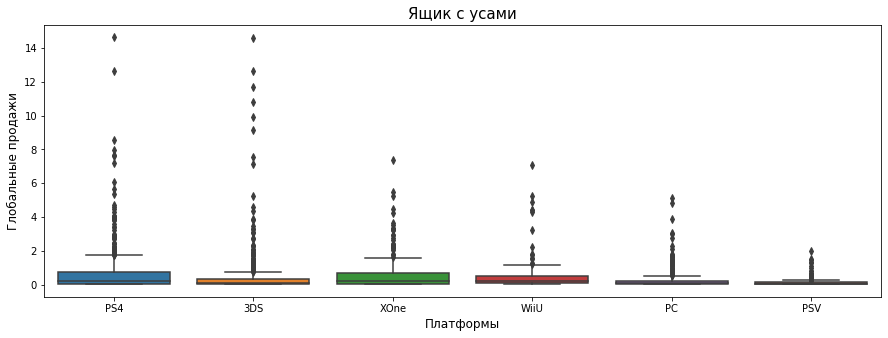

In [35]:
plt.figure(figsize=(15,5))
sns.boxplot(data=actual_platform, x='platform', y='all_sales')
plt.title('Ящик с усами', fontsize=15)
plt.xlabel('Платформы', fontsize=12)
plt.ylabel('Глобальные продажи',fontsize=12)
plt.show()

*Замечаем, что:*
- Больше всех продаж у 3DS, затем PC, после PSV, PS4, XOne и WiiU на последнем месте.
- Но при этом среднее больше всего у PS4, затем XOne, WiiU, 3DS, PC и PSV



Хоть больше всего продаж у 3DS, среднее больше у PS4, потому что (как мы видим по распределению)  - у 3DS данные представлены за меньшее количество лет, нежели PS4. У PSV большое количество продаж, но как мы видим - среднее этих продаж очень мало.


***Посмотрим, как влияют на продажи внутри одной популярной платформы (возьмём 3DS) отзывы пользователей и критиков. Построим диаграмму рассеяния и посчитаем корреляцию между отзывами и продажами.***

In [36]:
game_3ds= actual_games[actual_games['platform']=='3DS']

Посмотрим на корреляцию между оценками пользователей и продажами 3DS

In [37]:
game_3ds['user_score'].corr(game_3ds['all_sales'])

0.222305117884012

Построим диаграмму рассеяния

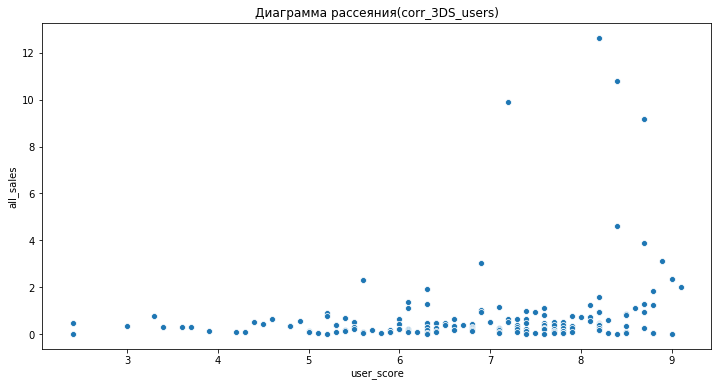

In [38]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='user_score', y='all_sales', data=game_3ds)
plt.title('Диаграмма рассеяния(corr_3DS_users)')
plt.show()

*Корреляция Пирсона между оценками пользователей и продажами 3DS мала. И по диаграмме рассеяния мы это наглядно видим. Оценки пользователей не очень влияют на продажи данной платформы. То есть покупатели 3DS не особо обращают внимание на оценки пользователей.*

Посмотрим на корреляцию между оценками критиков и продажами 3DS

In [39]:
game_3ds['critic_score'].corr(game_3ds['all_sales'])

0.34821555174929825

Построим диаграмму рассеяния

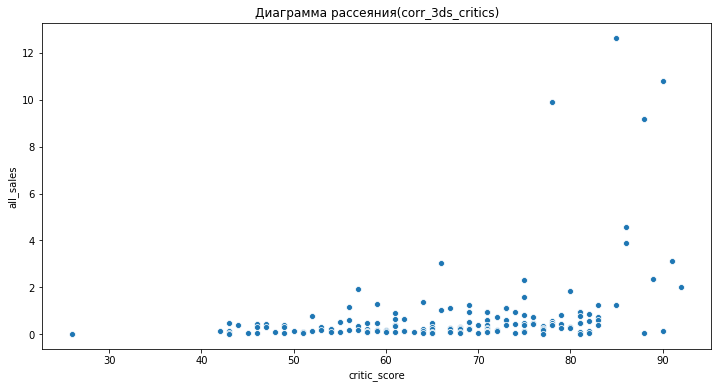

In [40]:
plt.figure(figsize=(12,6))
sns.scatterplot(x='critic_score', y='all_sales', data=game_3ds)
plt.title('Диаграмма рассеяния(corr_3ds_critics)')
plt.show()

*Видим, что корреляция Пирсона между оценками критиков и продажами 3DS не очень высокая(умеренная), но больше чем корреляция между оценками пользователей и продажами. То есть покупатели 3DS прислушиваются больше к критикам, чем к пользователям.* Посмотрим теперь и на остальные платформы.

***Соотнесём выводы с продажами игр на других платформах.***

Напишем функцию, которая по названию платформы будет выводить корреляции и диаграммы рассеяния.

In [41]:
def corr_platform(name_platform):
    platform = actual_platform[actual_platform['platform']==name_platform]
    print('Корреляция между отзывами критиков и продажами платформы', name_platform, platform['critic_score'].corr(platform['all_sales']))
    print('Корреляция между отзывами пользователей и продажами платформы', name_platform, platform['user_score'].corr(platform['all_sales']))
    plt.figure(figsize=(12,6))
    sns.scatterplot(x='critic_score', y='all_sales', data=platform)
    plt.title('Диаграмма рассеяния'+'(отзывы критиков/продажы платформы '+ name_platform +')')
    plt.show()
    plt.figure(figsize=(12,6))
    sns.scatterplot(x='user_score', y='all_sales', data=platform)
    plt.title('Диаграмма рассеяния'+'(отзывы пользователей/продажы платформы '+ name_platform +')')
    plt.show()
    print('____________________________________________________________________________________________________________________________')

In [42]:
actual_platform['platform'].unique()

array(['PS4', '3DS', 'XOne', 'WiiU', 'PC', 'PSV'], dtype=object)

Взглянем на интересующую информацию об этих 6 платформах(с помощью цикла)

Корреляция между отзывами критиков и продажами платформы PS4 0.40656790206178095
Корреляция между отзывами пользователей и продажами платформы PS4 -0.031957110204556424


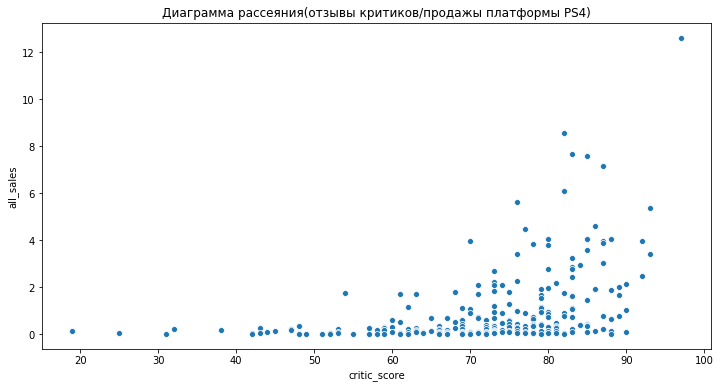

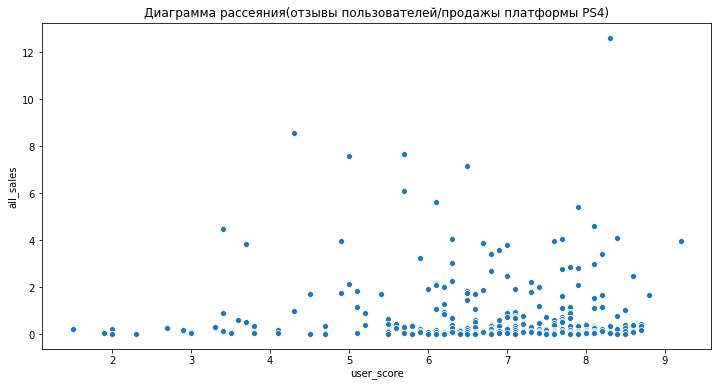

____________________________________________________________________________________________________________________________
Корреляция между отзывами критиков и продажами платформы 3DS 0.34821555174929825
Корреляция между отзывами пользователей и продажами платформы 3DS 0.222305117884012


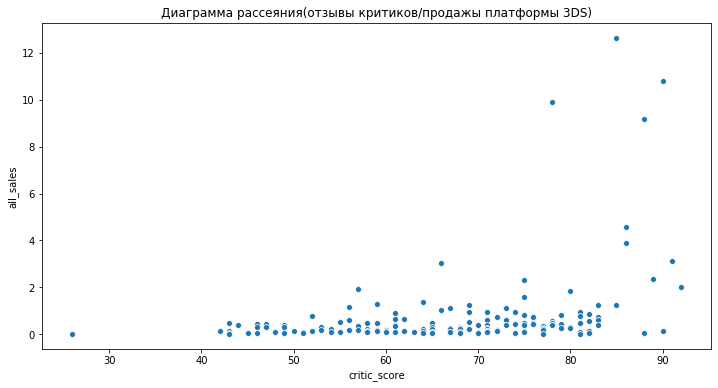

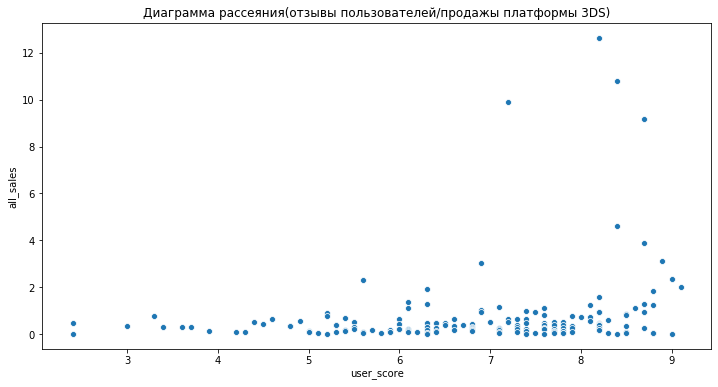

____________________________________________________________________________________________________________________________
Корреляция между отзывами критиков и продажами платформы XOne 0.4169983280084017
Корреляция между отзывами пользователей и продажами платформы XOne -0.06892505328279414


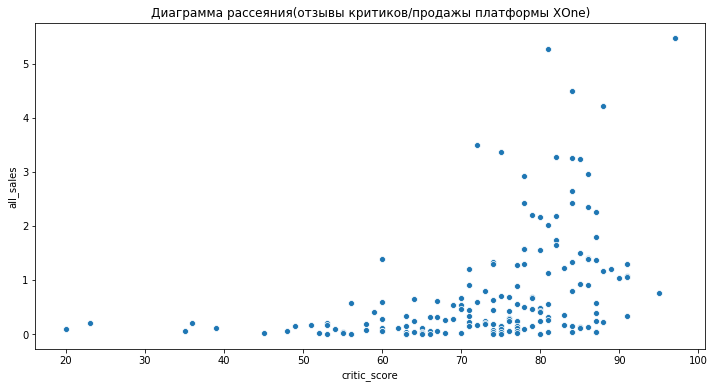

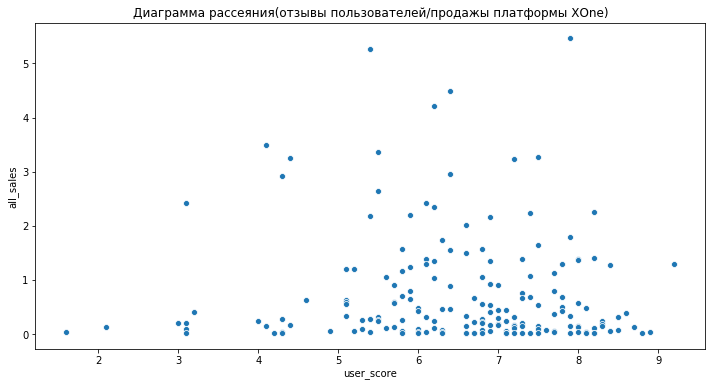

____________________________________________________________________________________________________________________________
Корреляция между отзывами критиков и продажами платформы WiiU 0.34837976012017485
Корреляция между отзывами пользователей и продажами платформы WiiU 0.4002190202148617


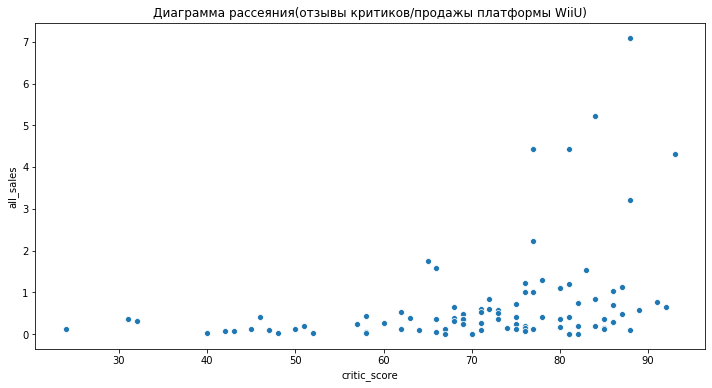

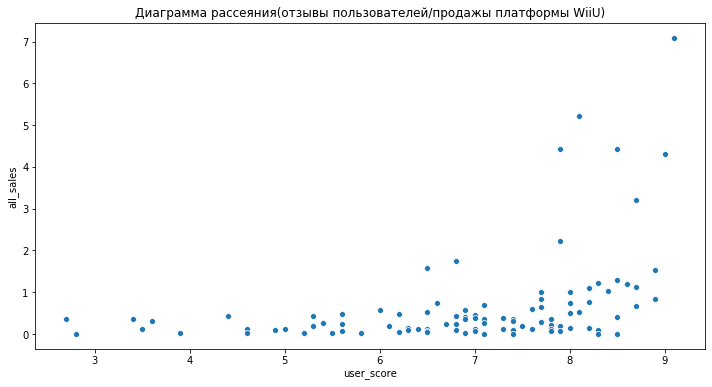

____________________________________________________________________________________________________________________________
Корреляция между отзывами критиков и продажами платформы PC 0.3372698409157572
Корреляция между отзывами пользователей и продажами платформы PC -0.01636530103008556


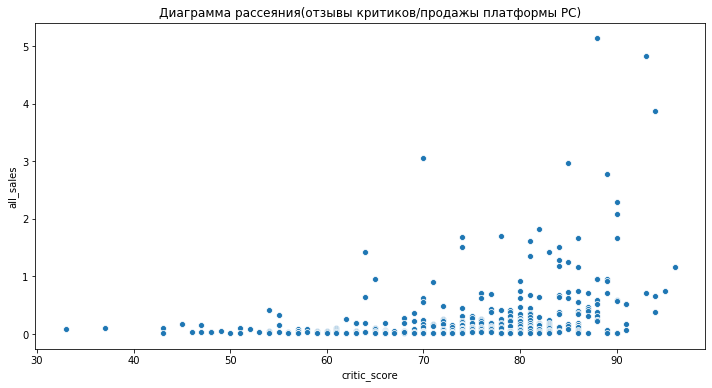

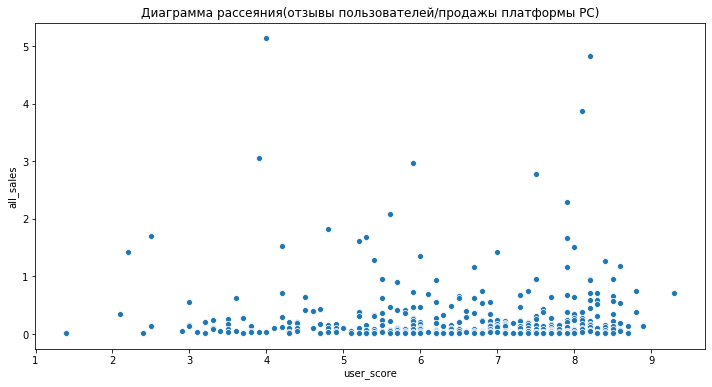

____________________________________________________________________________________________________________________________
Корреляция между отзывами критиков и продажами платформы PSV 0.13176292727608935
Корреляция между отзывами пользователей и продажами платформы PSV 0.0134887568358865


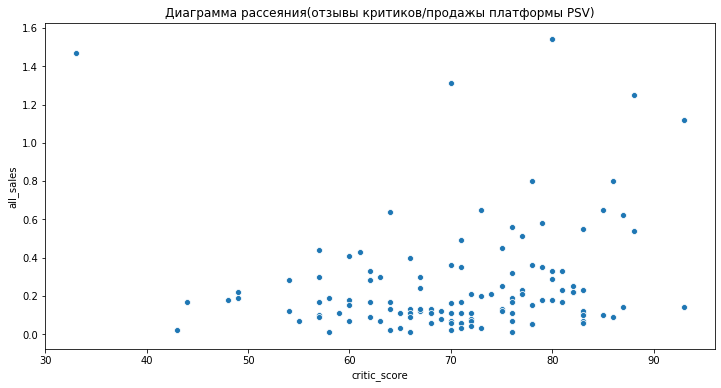

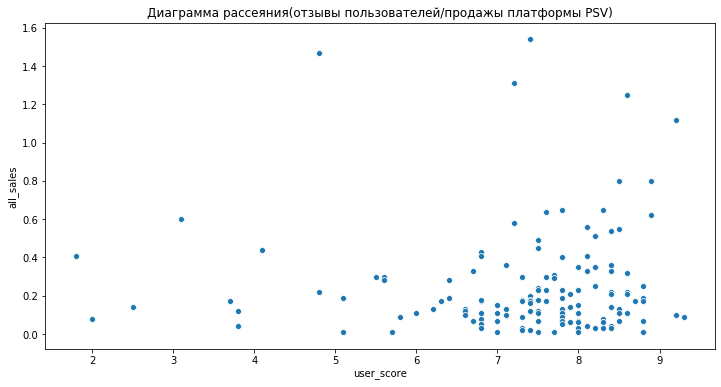

____________________________________________________________________________________________________________________________


In [43]:
for i in (['PS4', '3DS', 'XOne', 'WiiU', 'PC', 'PSV']):
    corr_platform(i)

*Делаем вывод, что:*

    1. PS4. Корреляция между отзывами критиков и продажами платформы (0.40656790206178095 - умеренная корреляция) > корреляция между отзывами пользователей и продажами (она вообще отрицательная и по модулю очень маленькая, то есть связи между отзывами пользователей и продажами практически нет). Покупатели ориентируются на мнению критиков.
    2. 3DS. Корреляции между отзывами критиков и продажами/между отзывами пользователей и продажами - обе положительны, но корреляция между отзывами критиков больше. Поэтому пользователи 3DS чаще ориентируются на мнение критиков, а не пользователей.
    3. XOne. Корреляция между отзывами пользователей и продажами очень мала, связи практически нет. А вот корреляция между отзывами критиков и продажами равна 0.4169... - умеренная корреляция. То есть клиенты прислушиваются к мнению критиков, а не пользователей.
    4. WiiU. У данной платформы обе корреляции положительные и умеренные(но даже корреляция между отзывами пользователей и продажами больше другой), то есть клиенты данной платформы прислушиваются к мнению критиков и пользователей, но даже чаще к пользователям)
    5. PC. Связь между продажами и отзывами отсутствует, а корреляция между отзывами критиков и продажами платформы - умеренная и положительная, таким образом покупатели обращают внимание на мнение критиков, а не пользователей.
    6. PSV. Корреляция между отзывами критиков и продажами крайне мала,но корреляция между отзывами практически отсутствует.
    
*Таким образом у большинства платформ (PS4,3DS,XOne,PC,PSV) клиенты больше слушают мнение критиков, а корреляция между отзывами пользователей и продажами либо отсутствует, либо очень мала. И только клиенты платформы WiiU слушают как критиков, так и пользователей, но пользователей даже больше*

***Посмотрим на общее распределение игр по жанрам.***

С помощью сводной таблицы найдём суммарные продажи для каждого жанра 

In [44]:
actual_genre = actual_platform.pivot_table(index='genre', values='all_sales', aggfunc='sum').sort_values(
    by='all_sales', ascending=False).reset_index()
actual_genre.columns=['genre','all_sales_sum']

Взглянем на таблицу:

In [45]:
actual_genre

,genre,all_sales_sum
0,Action,250.23
1,Shooter,186.84
2,Role-Playing,167.28
3,Sports,103.03
4,Platform,65.56
5,Racing,49.88
6,Simulation,45.05
7,Misc,44.54
8,Fighting,30.68
9,Strategy,22.10


Построим столбчатую диаграмму для наглядности:

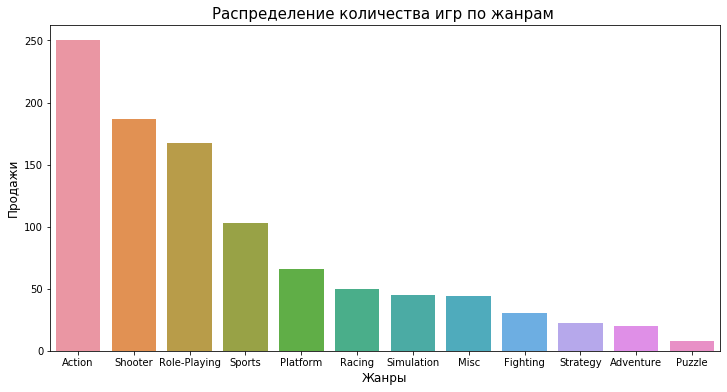

In [46]:
plt.figure(figsize=(12,6))
plt.title('Распределение количества игр по жанрам ',fontsize=15)
sns.barplot(data=actual_genre, x='genre', y='all_sales_sum')
plt.xlabel('Жанры',fontsize=12)
plt.ylabel('Продажи',fontsize=12)
plt.show()

Таким образом больше всего продаж у Action, а на последнем месте Puzzle. Racing, simulation, misc - имеют примерно одинаковые примерно одинаковые продажи.

### Вывод

Мы провели исследовательский анализ, построиги графики, диаграмму, посмотрели распределения, нашли корреляции. И поняли, что:

 Только с 1990 года увеличивается количество выпускаемых игр в год, а с 2008 виден спад количества
 
 Топ-3 платформы с наибольшими продажами это PS2, X360, PS3
 
 1) Игры на платформе PS2 продавались с 2000 по 2011 год. То есть PS2 "просущестовал" 12 лет, на 5 год сущестования(2004г) были самые большие продажи, а на последний год существования (2011г) их было меньше всего.
2) Игры на платформе X360 продавались с 2005 по 2016 год. То есть X360 "просущестовал" 12 лет, на 6 год существоания (2010г) были самые большие продажи, а на последний год сущестования (2016г) их было меньше всего.
3) Игры на платформе PS3 продавались с 2005 по 2016 год. То есть PS3 "просущестовал" 12 лет, на 7 год существоания (2011г) были самые большие продажи, а  на первый год сущестования (2005г) их было меньше всего.
4) На 6 год сущестования PS2 (2005г) появились новые платформы PS3 и X360, а уже в 2011г (на 12 год сущестования) PS2 "исчезла", то есть на 6 год сущестования PS3 и X360
5) А вот PS2 и X360 "появились" одновременно в 2005г и "исчезли" одновременно в 2016г. Но самые маленькие и большие продажи этих двух платформ пришлись на разные годы сущестования. В 2016 году они теряют своё могущество.

 За актуальный период мы взяли данные 2010 года и позже.
 
 
    1. Продажи DS за данный период постоянно падают, к 2013 году они сошли на нет, для анализа (прогноза на 2017 год) - это платформа не нужна.
    2. С 2013 по 2015 видим повышение количества продаж PS4, с 2015-2016 видим спад продаж, но они все равно остаются на неплохом уровне - на 2017 это потенциально прибыльная платформа
    3. Продажи 3DS постоянно подают, к 2016 году ее продажи очень малы - но все же за 2017 год эта платформа потенциально должна принести прибыль.
    4. Продажи Wii постоянно подают, к 2016 году ее продажи сошли на нет, поэтому в 2017 году данная платформа не будет потенциально прибыльной
    5. C 2013 по 2015 увеличиваются продаж XOne, к 2016 видим спад, но продажи все равно неплохие, за 2017 год эта платформа потенциально должна принести прибыль
    6. С 2015-2016 замечаем понижение продаж WiiU, а с 2012-2014 наоборот было повышение. 
    7. С 2011-2016 видим спад числа продаж PC
    8. Продажи PSP с 2010 по 2015 падали, данная платформа для прогноза не нужна
    9. С 2011-2012  и с 2013-2014 видим повышение числа продаж PSV, а с 2012-2013 и с 2014-2016 понижение продаж, эта платформа потенциально должна принести прибыль
    
 Больше всех продаж у 3DS, затем PC, после PSV, PS4, XOne и WiiU на последнем месте.
 Но при этом среднее больше всего у PS4, затем XOne, WiiU, 3DS, PC и PSV
 
 у большинства платформ (PS4,3DS,XOne,PC,PSV) клиенты больше слушают мнение критиков, а корреляция между отзывами пользователей  и продажами либо отсутствует, либо очень мала. И только клиенты платформы WiiU слушают как критиков, так и пользователей, но пользователей даже больше

## Шаг 4. Составьте портрет пользователя каждого региона

Для пользователя каждого региона (NA, EU, JP) 

Создадим сводные таблицы:

In [47]:
actual_platform_na=actual_platform.pivot_table(index='platform',values='na_sales',aggfunc='sum').sort_values(by='na_sales', ascending=False).reset_index().head(5)
actual_genre_na=actual_platform.pivot_table(index='genre',values='na_sales',aggfunc='sum').sort_values(by='na_sales', ascending=False).reset_index().head(5)
actual_rating_na=actual_platform.pivot_table(index='rating',values='na_sales',aggfunc='sum').sort_values(by='na_sales', ascending=False).reset_index().head(5)

actual_platform_eu=actual_platform.pivot_table(index='platform',values='eu_sales',aggfunc='sum').sort_values(by='eu_sales', ascending=False).reset_index().head(5)
actual_genre_eu=actual_platform.pivot_table(index='genre',values='eu_sales',aggfunc='sum').sort_values(by='eu_sales', ascending=False).reset_index().head(5)
actual_rating_eu=actual_platform.pivot_table(index='rating',values='eu_sales',aggfunc='sum').sort_values(by='eu_sales', ascending=False).reset_index().head(5)

actual_platform_jp=actual_platform.pivot_table(index='platform',values='jp_sales',aggfunc='sum').sort_values(by='jp_sales', ascending=False).reset_index().head(5)
actual_genre_jp=actual_platform.pivot_table(index='genre',values='jp_sales',aggfunc='sum').sort_values(by='jp_sales', ascending=False).reset_index().head(5)
actual_rating_jp=actual_platform.pivot_table(index='rating',values='jp_sales',aggfunc='sum').sort_values(by='jp_sales', ascending=False).reset_index().head(5)

***Посмотрим на пользователя NA:***

In [48]:
actual_platform_na

,platform,na_sales
0,PS4,108.74
1,XOne,93.12
2,3DS,83.11
3,PC,39.87
4,WiiU,38.10


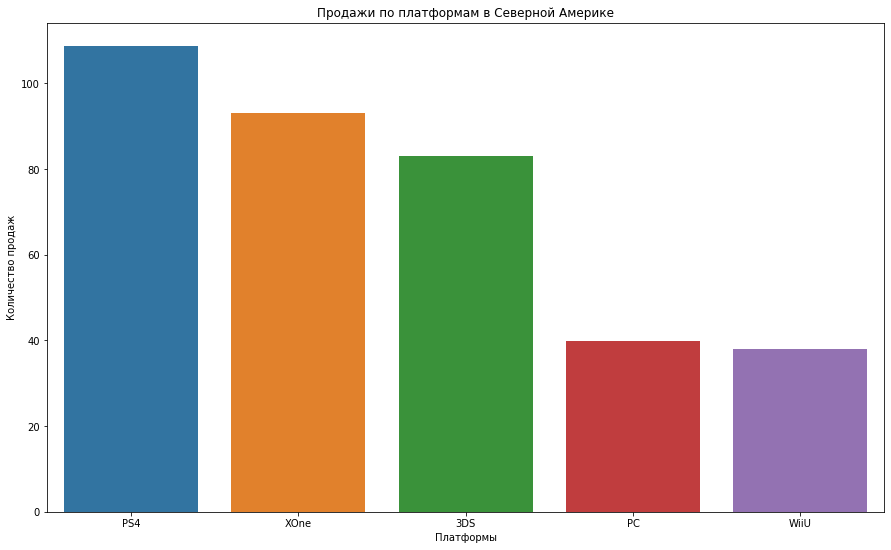

In [49]:
plt.figure(figsize=(15,9))
sns.barplot(x=actual_platform_na['platform'],y=actual_platform_na['na_sales'])
plt.title("Продажи по платформам в Северной Америке")
plt.xlabel("Платформы")
plt.ylabel("Количество продаж")
plt.show()

*Таким образом, топ-5 платформ по продажам(PS4,XOne,3DS,PC,WiiU) в Северной Америке; самые большие продажи у PS4, причем PC и WiiU (4 и 5 место) имеют примерно одинаковые продажи и они намного меньше продаж остальных платформ, входящих в топ-5 по продажам.*

In [50]:
actual_genre_na

,genre,na_sales
0,Action,94.48
1,Shooter,82.90
2,Role-Playing,55.36
3,Sports,40.04
4,Platform,26.97


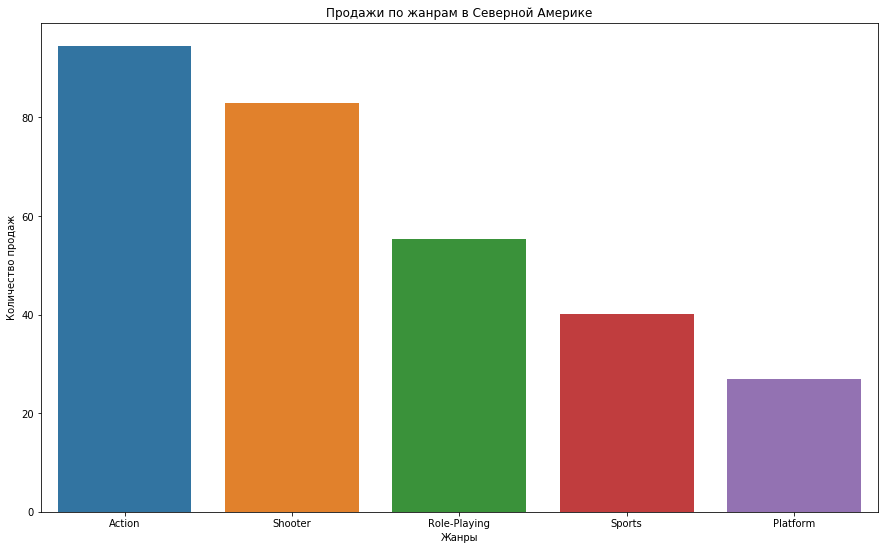

In [51]:
plt.figure(figsize=(15,9))
sns.barplot(x=actual_genre_na['genre'],y=actual_genre_na['na_sales'])
plt.title("Продажи по жанрам в Северной Америке")
plt.xlabel("Жанры")
plt.ylabel("Количество продаж")
plt.show()

*Таким образом, в топ-5 жанров по продажам В Северной Америке входят: action,shooter,relo-playing,sports,platform (в порядке убывания продаж), причем последние 3 жанра имеют намного меньше продаж первых двух.*

In [52]:
actual_rating_na

,rating,na_sales
0,M,114.25
1,E,81.41
2,T,53.27
3,E10+,46.26
4,EC,0.09


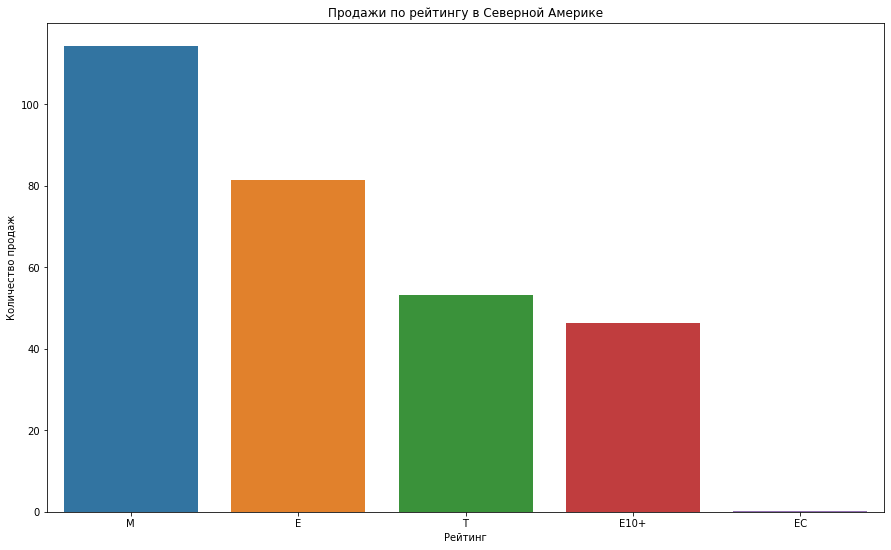

In [53]:
plt.figure(figsize=(15,9))
sns.barplot(x=actual_rating_na['rating'],y=actual_rating_na['na_sales'])
plt.title("Продажи по рейтингу в Северной Америке")
plt.xlabel("Рейтинг")
plt.ylabel("Количество продаж")
plt.show()

*Таким образом, продажи зависят от рейтинга в Северной Америке. Так допустим продажи рейтинга EC практически равны нулю. А больше всего продаж у игр рейтинга M, продажи рейтинга T и E10+(3 и 4 место) примерно одинаковы.*

***Посмотрим на пользователя EU:***

In [54]:
actual_platform_eu

,platform,eu_sales
0,PS4,141.09
1,PC,70.50
2,3DS,61.46
3,XOne,51.59
4,WiiU,25.13


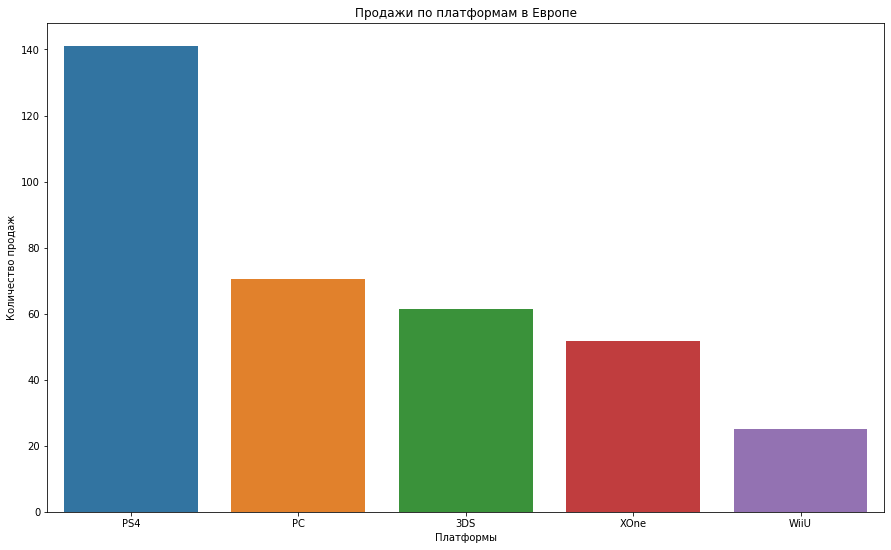

In [55]:
plt.figure(figsize=(15,9))
sns.barplot(x=actual_platform_eu['platform'],y=actual_platform_eu['eu_sales'])
plt.title("Продажи по платформам в Европе")
plt.xlabel("Платформы")
plt.ylabel("Количество продаж")
plt.show()

*Таким образом, в Европе больше всего (причем существенно) продаж у PS4, а меньше всего продаж у платформы WiiU*

In [56]:
actual_genre_eu

,genre,eu_sales
0,Action,92.10
1,Shooter,75.31
2,Role-Playing,44.91
3,Sports,44.90
4,Racing,22.37


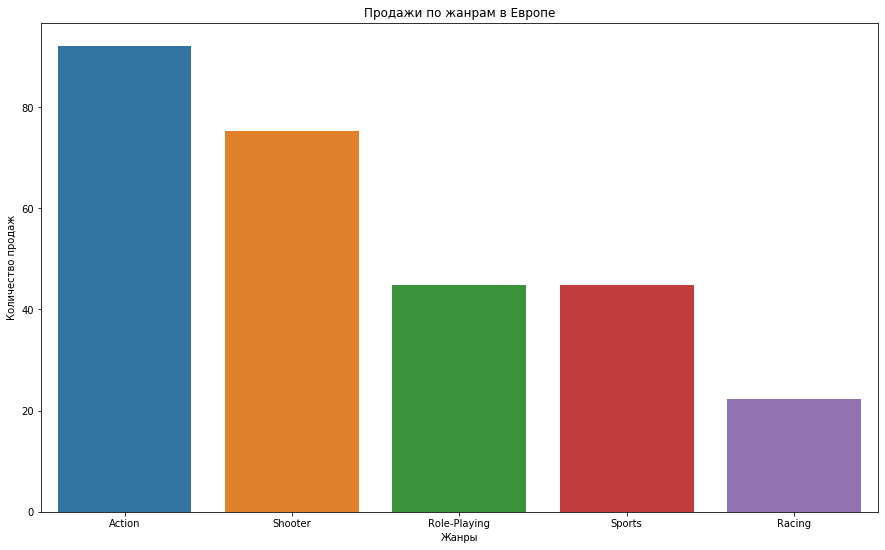

In [57]:
plt.figure(figsize=(15,9))
sns.barplot(x=actual_genre_eu['genre'],y=actual_genre_eu['eu_sales'])
plt.title("Продажи по жанрам в Европе")
plt.xlabel("Жанры")
plt.ylabel("Количество продаж")
plt.show()

*Таким образом,больше всего продаж в Европе у игр жанра action, меньше всего у racing, а у role-playing и sports(3 и 4 место) имеют примерно одинаковые продажи.*

In [58]:
actual_rating_eu

,rating,eu_sales
0,M,117.69
1,E,83.12
2,T,49.89
3,E10+,35.33
4,RP,0.03


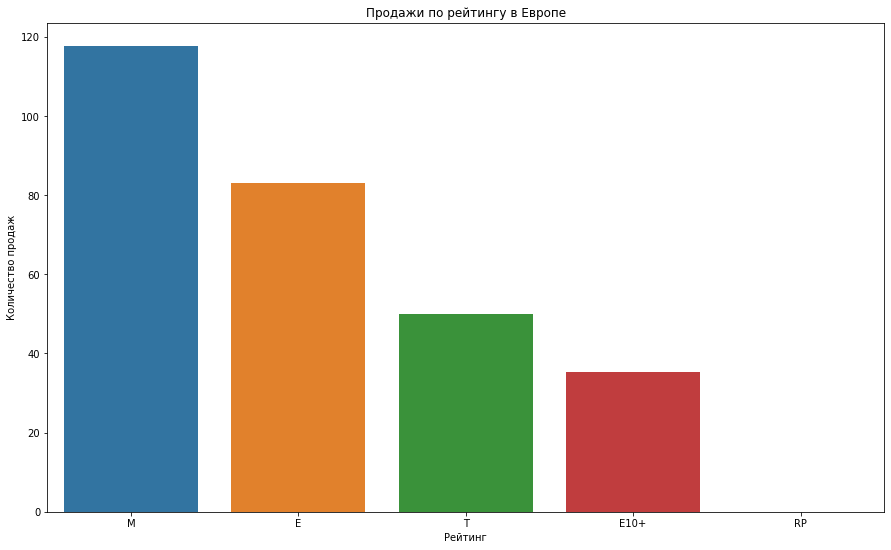

In [59]:
plt.figure(figsize=(15,9))
sns.barplot(x=actual_rating_eu['rating'],y=actual_rating_eu['eu_sales'])
plt.title("Продажи по рейтингу в Европе")
plt.xlabel("Рейтинг")
plt.ylabel("Количество продаж")
plt.show()

*Таким образом, В Европе продажи зависят от рейтинга, продажи игр рейтинга RP очень низкие по сравнению с остальными рейтингами, входящими в топ-5 по продажам. А больше всего продаж у рейтинга M*

***Посмотрим на пользователя JP:***

In [60]:
actual_platform_jp

,platform,jp_sales
0,3DS,100.64
1,PSV,21.84
2,PS4,15.96
3,WiiU,13.01
4,XOne,0.34


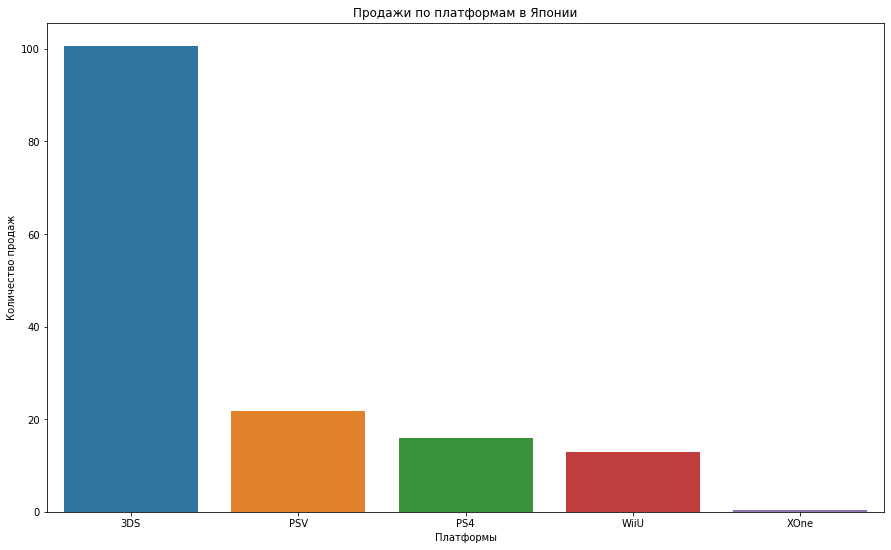

In [61]:
plt.figure(figsize=(15,9))
sns.barplot(x=actual_platform_jp['platform'],y=actual_platform_jp['jp_sales'])
plt.title("Продажи по платформам в Японии")
plt.xlabel("Платформы")
plt.ylabel("Количество продаж")
plt.show()

*Таким образом, в Японии очевидно с большим отрывком по продажам лидирует платформа 3DS, на последнем пятом месте по продажам стоит платформа XOne с очень низкими продажами по сравнению с остальными платформами, входящими в топ-5 по продажам.*

In [62]:
actual_genre_jp

,genre,jp_sales
0,Role-Playing,54.19
1,Action,36.54
2,Platform,10.71
3,Misc,10.70
4,Simulation,10.64


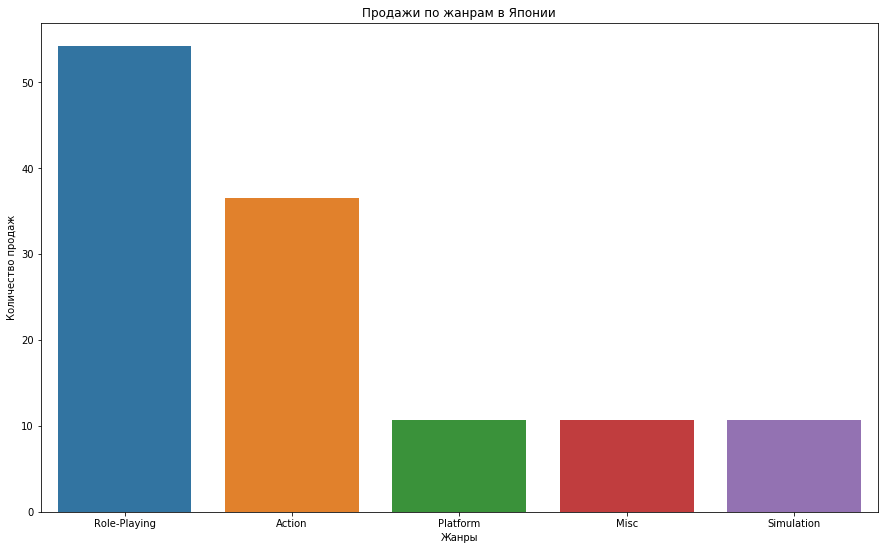

In [63]:
plt.figure(figsize=(15,9))
sns.barplot(x=actual_genre_jp['genre'],y=actual_genre_jp['jp_sales'])
plt.title("Продажи по жанрам в Японии")
plt.xlabel("Жанры")
plt.ylabel("Количество продаж")
plt.show()

*Таким образом, в Японии больше всего продаж у игр жанров role-playing и action, а platform,misc,simulation имеют примерно одиноковые продажи, которые намного ниже продаж role-playing,action.*

In [64]:
actual_rating_jp

,rating,jp_sales
0,E,29.76
1,T,16.50
2,M,9.28
3,E10+,8.32
4,EC,0.00


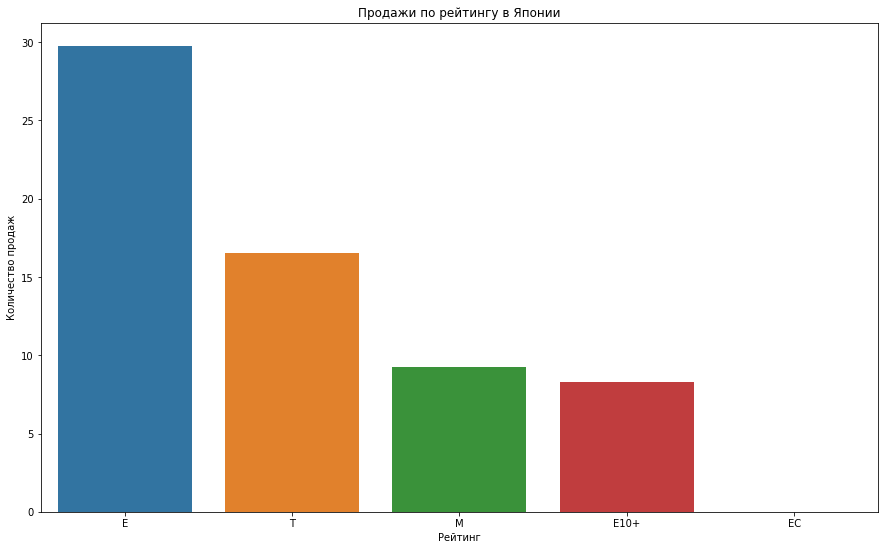

In [65]:
actual_rating_na
plt.figure(figsize=(15,9))
sns.barplot(x=actual_rating_jp['rating'],y=actual_rating_jp['jp_sales'])
plt.title("Продажи по рейтингу в Японии")
plt.xlabel("Рейтинг")
plt.ylabel("Количество продаж")
plt.show()

*Таким образом, в Японии только 4 рейтинга у игр (EC на 5 место имеет 0 продаж), причем очевидным лидером по продажам является рейтинг E.*

В нашем датасете предостаточно игр без рейтинга. Рассмотрим их:

**Продажи игр без рейтинга в Северной Америке**

In [66]:
actual_platform_na_nan=actual_platform[actual_platform['rating'].isna()].pivot_table(index='platform',values='na_sales',aggfunc='sum').sort_values(by='na_sales', ascending=False).reset_index().head(5)

In [67]:
actual_platform_na_nan

,platform,na_sales
0,3DS,30.35
1,PS4,23.77
2,XOne,14.63
3,WiiU,6.71
4,PC,2.65


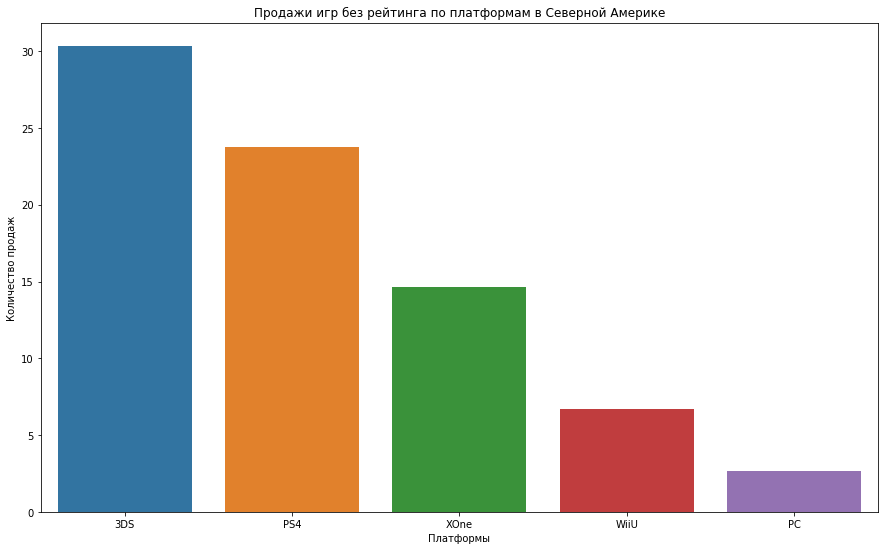

In [68]:
plt.figure(figsize=(15,9))
sns.barplot(x=actual_platform_na_nan['platform'],y=actual_platform_na_nan['na_sales'])
plt.title("Продажи игр без рейтинга по платформам в Северной Америке")
plt.xlabel("Платформы")
plt.ylabel("Количество продаж")
plt.show()

В Северной Америке по продажам игр без рейтинга лидирует 3DS, на 5 месте находиться PC

In [69]:
actual_genre_na_nan=actual_platform[actual_platform['rating'].isna()].pivot_table(index='genre',values='na_sales',aggfunc='sum').sort_values(by='na_sales', ascending=False).reset_index().head(5)

In [70]:
actual_genre_na_nan

,genre,na_sales
0,Role-Playing,22.65
1,Shooter,17.56
2,Action,16.68
3,Fighting,7.08
4,Misc,5.02


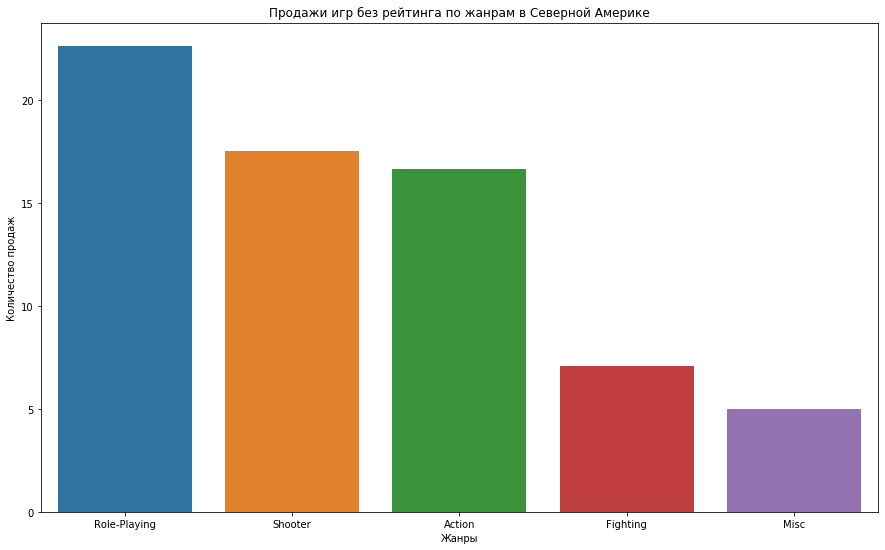

In [71]:
plt.figure(figsize=(15,9))
sns.barplot(x=actual_genre_na_nan['genre'],y=actual_genre_na_nan['na_sales'])
plt.title("Продажи игр без рейтинга по жанрам в Северной Америке")
plt.xlabel("Жанры")
plt.ylabel("Количество продаж")
plt.show()

На первом месте по продажам игр без рейтинга лидирует role-playing жанр, причем 2 и 3 место (shooter и action) имеют примерно одинаковые продажи, на последнем месте жанр misc.

**Продажи игр без рейтинга в Европе**

In [72]:
actual_platform_eu_nan=actual_platform[actual_platform['rating'].isna()].pivot_table(index='platform',values='eu_sales',aggfunc='sum').sort_values(by='eu_sales', ascending=False).reset_index().head(5)

In [73]:
actual_platform_eu_nan

,platform,eu_sales
0,PS4,27.99
1,3DS,25.02
2,PC,8.74
3,XOne,8.30
4,WiiU,4.01


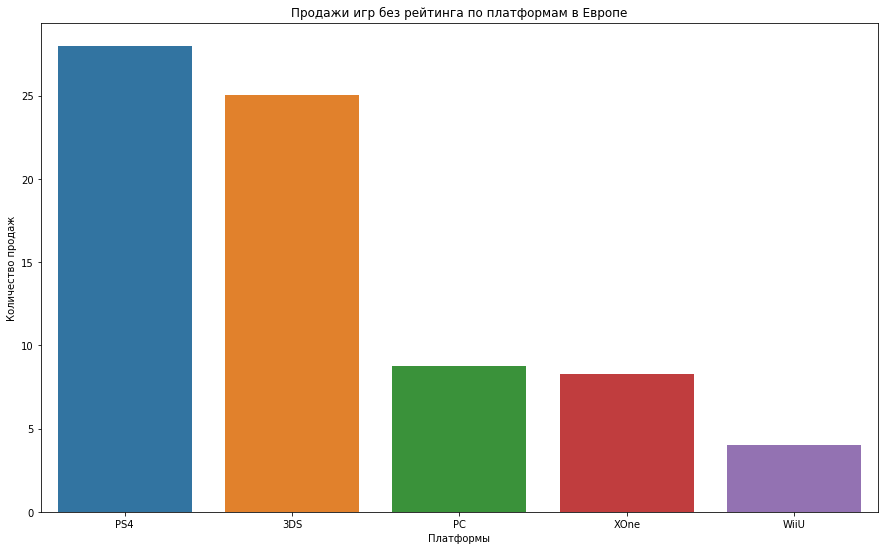

In [74]:
plt.figure(figsize=(15,9))
sns.barplot(x=actual_platform_eu_nan['platform'],y=actual_platform_eu_nan['eu_sales'])
plt.title("Продажи игр без рейтинга по платформам в Европе")
plt.xlabel("Платформы")
plt.ylabel("Количество продаж")
plt.show()

В Европе больше всего продаж у PS4 и 3DS, они лидируют с большим отрывом, PC и XOne (3 и 4 место) имеют примерно одинаковое количество продаж на 5 месте WiiU.

In [75]:
actual_genre_eu_nan=actual_platform[actual_platform['rating'].isna()].pivot_table(index='genre',values='eu_sales',aggfunc='sum').sort_values(by='eu_sales', ascending=False).reset_index().head(5)

In [76]:
actual_genre_eu_nan

,genre,eu_sales
0,Role-Playing,17.10
1,Shooter,15.46
2,Action,14.73
3,Simulation,5.94
4,Misc,5.52


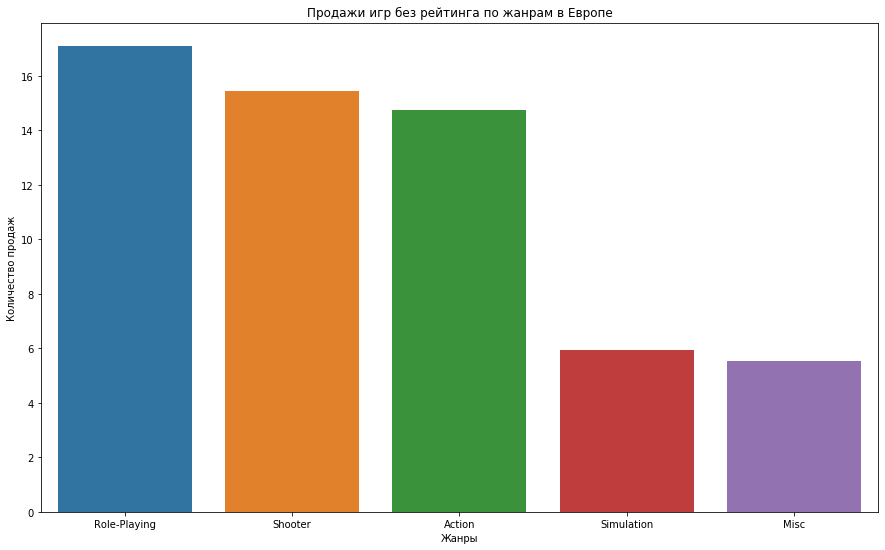

In [77]:
plt.figure(figsize=(15,9))
sns.barplot(x=actual_genre_eu_nan['genre'],y=actual_genre_eu_nan['eu_sales'])
plt.title("Продажи игр без рейтинга по жанрам в Европе")
plt.xlabel("Жанры")
plt.ylabel("Количество продаж")
plt.show()

С большим отрывом лидируют role-playing,shooter,action. А вот simulation и misc (4 и 5 место) имеют намного меньше продаж.

**Продажи игр без рейтинга в Японии**

In [78]:
actual_platform_jp_nan=actual_platform[actual_platform['rating'].isna()].pivot_table(index='platform',values='jp_sales',aggfunc='sum').sort_values(by='jp_sales', ascending=False).reset_index().head(5)

In [79]:
actual_platform_jp_nan

,platform,jp_sales
0,3DS,65.70
1,PSV,13.09
2,PS4,6.25
3,WiiU,2.84
4,XOne,0.05


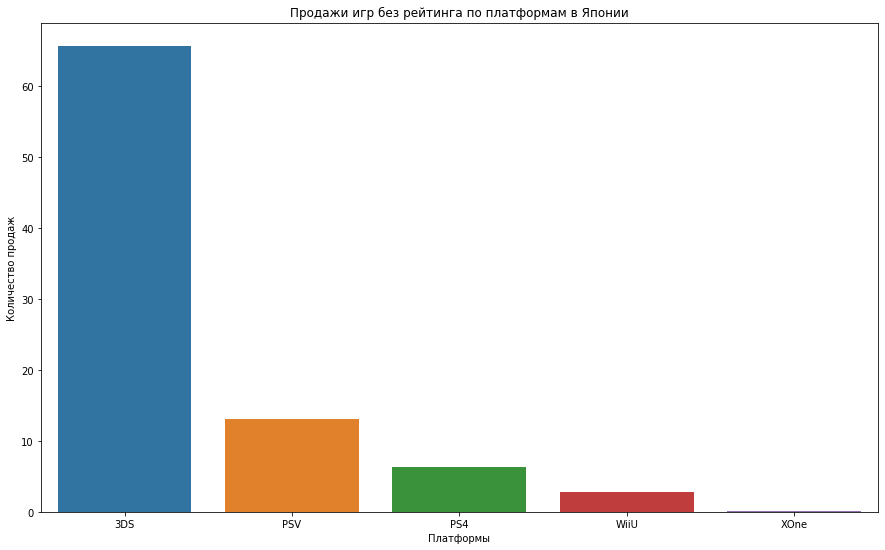

In [80]:
plt.figure(figsize=(15,9))
sns.barplot(x=actual_platform_jp_nan['platform'],y=actual_platform_jp_nan['jp_sales'])
plt.title("Продажи игр без рейтинга по платформам в Японии")
plt.xlabel("Платформы")
plt.ylabel("Количество продаж")
plt.show()

В Японии с абсолютным отрывом лидирует 3DS, а вот почти нулевые продажи имеет платформа Xone (5 место)

In [81]:
actual_genre_jp_nan=actual_platform[actual_platform['rating'].isna()].pivot_table(index='genre',values='jp_sales',aggfunc='sum').sort_values(by='jp_sales', ascending=False).reset_index().head(5)

In [82]:
actual_genre_jp_nan

,genre,jp_sales
0,Role-Playing,39.63
1,Action,22.91
2,Misc,6.99
3,Adventure,4.60
4,Fighting,4.04


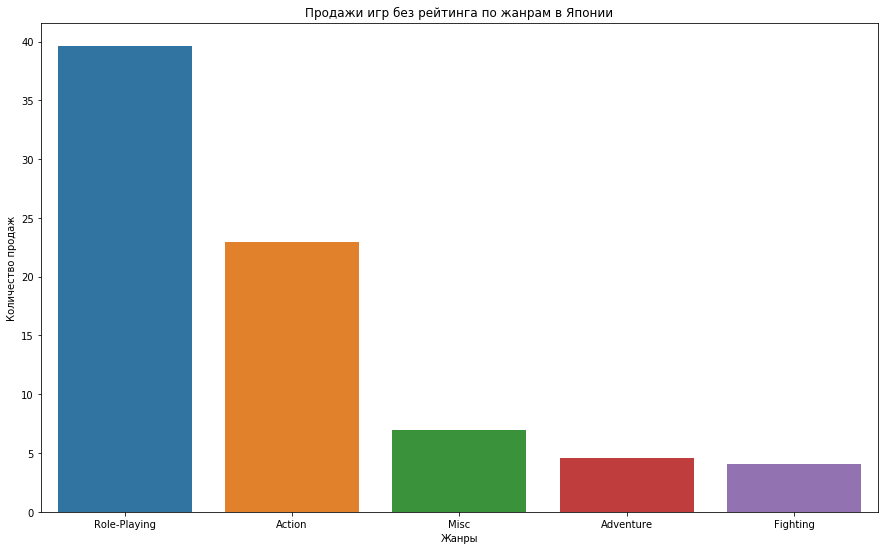

In [83]:
plt.figure(figsize=(15,9))
sns.barplot(x=actual_genre_jp_nan['genre'],y=actual_genre_jp_nan['jp_sales'])
plt.title("Продажи игр без рейтинга по жанрам в Японии")
plt.xlabel("Жанры")
plt.ylabel("Количество продаж")
plt.show()

В Японии больше всего продаж имеет жанр role-playing, на втором месте action. 3,4,5 место - Misc,Adventure,Fighting имеют примерно одинаковые низкие продажи.

### Вывод

Рейтинг ESRB:

    1)Северная Америка. Продажи рейтинга EC (5 место) практически равны нулю. А больше всего продаж у игр рейтинга M, продажи рейтинга T и E10+(3 и 4 место) примерно одинаковы.
    2)Европа. Продажи игр рейтинга RP (5 место) очень низкие по сравнению с остальными рейтингами, входящими в топ-5 по продажам. А больше всего продаж у рейтинга M*
    3)Япония. Только 4 рейтинга у игр в продаже (рейтинг EC на 5 месте имеет 0 продаж), причем очевидным лидером по продажам является рейтинг E. 
    
    У Японии всего 4 рейтинга, в Северной Америке и в Европе больше всего продат у рейтинга М, но у всех 3-ч регионов последнее место в топе рейтинг с крайне маленькими продажами по сравнению с другими (почти нулевые)
    
Платформы:

    1)Северная Америка. Топ-5 платформ по продажам(PS4,XOne,3DS,PC,WiiU); самые большие продажи у PS4, причем PC и WiiU (4 и 5 место) имеют примерно одинаковые продажи и они намного меньше продаж остальных платформ
    2)Европа.Больше всего (причем существенно) продаж у PS4, а меньше всего продаж у платформы WiiU
    3)Япония. Очевидно с большим отрывом по продажам лидирует платформа 3DS, на последнем пятом месте по продажам стоит платформа XOne с очень низкими продажами по сравнению с остальными платформами, входящими в топ-5 по продажам
    
    PS4 лидирует и в Северной Америке и в Европе, а также в Европе и в Северной Америке на 5 месте стоит платформа WiiU.
Жанры:

    1)Северная Америка. В топ-5 жанров по продажам входят: action,shooter,relo-playing,sports,platform (в порядке убывания продаж), причем последние 3 жанра имеют намного меньше продаж первых двух
    2)Европа. Больше всего продаж у игр жанра action, меньше всего у racing, а у role-playing и sports(3 и 4 место) имеют примерно одинаковые продажи
    3)Япония. Больше всего продаж у игр жанров role-playing и action, а platform,misc,simulation имеют примерно одиноковые продажи, которые намного ниже продаж role-playing,action.
    
   *Смотря на "портрет" пользователя Европы/Северной Америки/Японии, мы замечаем, что пользователь из Америки и Европы имеет достаточно много схожих "черт", а вот портрет пользователя из Японии не особо похож на них.*
   
   ***игры без рейтинга***
   
       1)Северная Америка. На первом месте по продажам игр без рейтинга лидирует role-playing жанр, причем 2 и 3 место (shooter и action) имеют примерно одинаковые продажи, на последнем месте жанр misc, лидирует 3DS, на 5 месте находиться PC
       2)Европа. С большим отрывом лидируют role-playing,shooter,action. А вот simulation и misc (4 и 5 место) имеют намного меньше продаж, больше всего продаж у PS4 и 3DS, они лидируют с большим отрывом, PC и XOne (3 и 4 место) имеют примерно одинаковое количество продаж на 5 месте WiiU
       3)Япония. Больше всего продаж имеет жанр role-playing, на втором месте action. 3,4,5 место - Misc,Adventure,Fighting имеют примерно одинаковые низкие продажи, с абсолютным отрывом лидирует 3DS, а вот почти нулевые продажи имеет платформа Xone (5 место)

## Шаг 5. Проверьте гипотезы

**Проверим гипотезу: Средние пользовательские рейтинги платформ Xbox One и PC одинаковые**

Для начала в переменной actual_xone сохраним только строки с платформой xone, а затем в переменной actual_pc сохраним только строки с платформой pc.

In [84]:
actual_xone=actual_games[(actual_games['platform']=='XOne')&(~(actual_games['user_score'].isna()))]
actual_pc=actual_games[(actual_games['platform']=='PC')&(~(actual_games['user_score'].isna()))]

*Проверка гипотезы о равенстве среднего двух генеральных совокупностей по взятым из них выборкам. В нашем случае мы проверяем равенство среднего пользовательского рейтинга платформы XOne и среднего пользовательского рейтинга платформы PC*

In [85]:
alpha = 0.05 #критический уровень статистической значимости(5%)

In [86]:
results = st.ttest_ind(actual_xone['user_score'], actual_pc['user_score'], equal_var=False) 

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу")

p-значение: 0.9519979495147267
Не получилось отвергнуть нулевую гипотезу


Получается, что средние пользовательские рейтинги платформ Xbox One и PC одинаковые. Гипотеза верна. Вероятность получить случайно равенство крайне мала.

**Проверим гипотезу: Средние пользовательские рейтинги жанров Action и Sports разные**

Для начала в переменной actual_action сохраним только строки с жанром action, а затем в переменной actual_sports сохраним только строки с жанром sports.

In [87]:
actual_action=actual_games[(actual_games['genre']=='Action')&(~(actual_games['user_score'].isna()))]
actual_sports=actual_games[(actual_games['genre']=='Sports')&(~(actual_games['user_score'].isna()))]

*Проверка гипотезы о равенстве среднего двух генеральных совокупностей по взятым из них выборкам. В нашем случае мы проверяем равенство среднего пользовательского рейтинга жанра Action и среднего пользовательского рейтинга жанра Sports*

In [88]:
results = st.ttest_ind(actual_action['user_score'], actual_sports['user_score'], equal_var=False) 

print('p-значение:', results.pvalue)

if results.pvalue < alpha:
    print("Отвергаем нулевую гипотезу")
else:
    print("Не получилось отвергнуть нулевую гипотезу")

p-значение: 5.704356296291296e-16
Отвергаем нулевую гипотезу


Получается, что средние пользовательские рейтинги жанров Action и Sports различные. Вероятность получить случайно отличие крайне мала.

### Вывод

Таким образом, 

    Средние пользовательские рейтинги платформ Xbox One и PC одинаковые - верная гипотеза;
    Средние пользовательские рейтинги жанров Action и Sports разные - верная гипотеза.

## Шаг 6. Напишите общий вывод

Мы вгзлянули на таблицу, на информацию о ней, посчитали пропуски (в столбцах Name, Year_of_Release, Genre, Critic_Score, User_Score, Rating), увидели, что дубликатов нет.
Привели названия столбцов к нижнему регистру. Заменили тип данных столбца user_score на вещественный, а столбца year_of_release на целолчисленный, часть пропусков в столбце year_of_release заменили на года от той же игры только другой платформы с помощью цикла, заменили tbd на Nan. Посчитали суммарные продажи во всех регионах и записали в столбец all_sales

*Мы провели исследовательский анализ данных: построили графики, посмотрели на распределения, построили столбчатые диаграммы, нашли корреляци*:

Только с 1990 года увеличивается количество выпускаемых игр в год, а с 2008 виден спад количества
 
 Топ-3 платформы с наибольшими продажами это PS2, X360, PS3
 
 1) Игры на платформе PS2 продавались с 2000 по 2011 год. То есть PS2 "просущестовал" 12 лет, на 5 год сущестования(2004г) были самые большие продажи, а на последний год существования (2011г) их было меньше всего.
2) Игры на платформе X360 продавались с 2005 по 2016 год. То есть X360 "просущестовал" 12 лет, на 6 год существоания (2010г) были самые большие продажи, а на последний год сущестования (2016г) их было меньше всего.
3) Игры на платформе PS3 продавались с 2005 по 2016 год. То есть PS3 "просущестовал" 12 лет, на 7 год существоания (2011г) были самые большие продажи, а  на первый год сущестования (2005г) их было меньше всего.
4) На 6 год сущестования PS2 (2005г) появились новые платформы PS3 и X360, а уже в 2011г (на 12 год сущестования) PS2 "исчезла", то есть на 6 год сущестования PS3 и X360
5) А вот PS2 и X360 "появились" одновременно в 2005г и "исчезли" одновременно в 2016г. Но самые маленькие и большие продажи этих двух платформ пришлись на разные годы сущестования. В 2016 году они теряют своё могущество.

 За актуальный период мы взяли данные 2010 года и позже.
 
 
    1. Продажи DS за данный период постоянно падают, к 2013 году они сошли на нет, для анализа (прогноза на 2017 год) - это платформа не нужна.
    2. С 2013 по 2015 видим повышение количества продаж PS4, с 2015-2016 видим спад продаж, но они все равно остаются на неплохом уровне - на 2017 это потенциально прибыльная платформа
    3. Продажи 3DS постоянно подают, к 2016 году ее продажи очень малы - но все же за 2017 год эта платформа потенциально должна принести прибыль.
    4. Продажи Wii постоянно подают, к 2016 году ее продажи сошли на нет, поэтому в 2017 году данная платформа не будет потенциально прибыльной
    5. C 2013 по 2015 увеличиваются продаж XOne, к 2016 видим спад, но продажи все равно неплохие, за 2017 год эта платформа потенциально должна принести прибыль
    6. С 2015-2016 замечаем понижение продаж WiiU, а с 2012-2014 наоборот было повышение. 
    7. С 2011-2016 видим спад числа продаж PC
    8. Продажи PSP с 2010 по 2015 падали, данная платформа для прогноза не нужна
    9. С 2011-2012  и с 2013-2014 видим повышение числа продаж PSV, а с 2012-2013 и с 2014-2016 понижение продаж, эта платформа потенциально должна принести прибыль
    
 Больше всех продаж у 3DS, затем PC, после PSV, PS4, XOne и WiiU на последнем месте.
 Но при этом среднее больше всего у PS4, затем XOne, WiiU, 3DS, PC и PSV
 
 у большинства платформ (PS4,3DS,XOne,PC,PSV) клиенты больше слушают мнение критиков, а корреляция между отзывами пользователей  и продажами либо отсутствует, либо очень мала. И только клиенты платформы WiiU слушают как критиков, так и пользователей, но пользователей даже больше

*Мы составили портрет пользователя каждого региона*

Рейтинг ESRB:

    1)Северная Америка. Продажи рейтинга EC (5 место) практически равны нулю. А больше всего продаж у игр рейтинга M, продажи рейтинга T и E10+(3 и 4 место) примерно одинаковы.
    2)Европа. Продажи игр рейтинга RP (5 место) очень низкие по сравнению с остальными рейтингами, входящими в топ-5 по продажам. А больше всего продаж у рейтинга M*
    3)Япония. Только 4 рейтинга у игр в продаже (рейтинг EC на 5 месте имеет 0 продаж), причем очевидным лидером по продажам является рейтинг E. 
    
    У Японии всего 4 рейтинга, в Северной Америке и в Европе больше всего продат у рейтинга М, но у всех 3-ч регионов последнее место в топе рейтинг с крайне маленькими продажами по сравнению с другими (почти нулевые)
    
Платформы:

    1)Северная Америка. Топ-5 платформ по продажам(PS4,XOne,3DS,PC,WiiU); самые большие продажи у PS4, причем PC и WiiU (4 и 5 место) имеют примерно одинаковые продажи и они намного меньше продаж остальных платформ
    2)Европа.Больше всего (причем существенно) продаж у PS4, а меньше всего продаж у платформы WiiU
    3)Япония. Очевидно с большим отрывом по продажам лидирует платформа 3DS, на последнем пятом месте по продажам стоит платформа XOne с очень низкими продажами по сравнению с остальными платформами, входящими в топ-5 по продажам
    
    PS4 лидирует и в Северной Америке и в Европе, а также в Европе и в Северной Америке на 5 месте стоит платформа WiiU.
Жанры:

    1)Северная Америка. В топ-5 жанров по продажам входят: action,shooter,relo-playing,sports,platform (в порядке убывания продаж), причем последние 3 жанра имеют намного меньше продаж первых двух
    2)Европа. Больше всего продаж у игр жанра action, меньше всего у racing, а у role-playing и sports(3 и 4 место) имеют примерно одинаковые продажи
    3)Япония. Больше всего продаж у игр жанров role-playing и action, а platform,misc,simulation имеют примерно одиноковые продажи, которые намного ниже продаж role-playing,action.
    
   *Смотря на "портрет" пользователя Европы/Северной Америки/Японии, мы замечаем, что пользователь из Америки и Европы имеет достаточно много схожих "черт", а вот портрет пользователя из Японии не особо похож на них.*
   
   ***игры без рейтинга***
   
       1)Северная Америка. На первом месте по продажам игр без рейтинга лидирует role-playing жанр, причем 2 и 3 место (shooter и action) имеют примерно одинаковые продажи, на последнем месте жанр misc, лидирует 3DS, на 5 месте находиться PC
       2)Европа. С большим отрывом лидируют role-playing,shooter,action. А вот simulation и misc (4 и 5 место) имеют намного меньше продаж, больше всего продаж у PS4 и 3DS, они лидируют с большим отрывом, PC и XOne (3 и 4 место) имеют примерно одинаковое количество продаж на 5 месте WiiU
       3)Япония. Больше всего продаж имеет жанр role-playing, на втором месте action. 3,4,5 место - Misc,Adventure,Fighting имеют примерно одинаковые низкие продажи, с абсолютным отрывом лидирует 3DS, а вот почти нулевые продажи имеет платформа Xone (5 место)

Проверили гипотезы (обе оказались верны):

    Средние пользовательские рейтинги платформ Xbox One и PC одинаковые;
    Средние пользовательские рейтинги жанров Action и Sports разные